<a href="https://colab.research.google.com/github/akshita-singh-2808/airlines_churn_prediction/blob/main/Notebooks/03_Segmentation_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# for modelling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/airlines_churn_prediction/outputs/Modeling_Dataset.csv')

In [ ]:
df.head()

,Loyalty Number,Male_Enc,Education_Enc,Marital_Enc,Card_Enc,Salary_Imputed,Salary_Was_Imputed,CLV,Tenure,Promo_Enroll,...,Flights_Q2,Flights_Q3,Flights_Q4,Flights_Trend,Flights_2017,Flights_2018,Churn,Formal_Churn,Behavioral_Churn,Never_Flew
0,480934,0,2,1,0,83236.0,False,3839.14,2,0,...,0,0,37,1,18,19,0,0,0,0
1,549612,1,1,2,0,73510.0,True,3839.61,2,0,...,0,0,58,-4,31,27,0,0,0,0
2,429460,1,1,0,0,73510.0,True,3839.75,4,0,...,0,18,0,-14,16,2,1,1,1,0
3,608370,1,1,0,0,73510.0,True,3839.75,5,0,...,35,0,0,-13,24,11,0,0,0,0
4,530508,1,2,1,0,103495.0,False,3842.79,4,0,...,0,0,0,15,11,26,0,0,0,0


In [ ]:
FEATURES = [
    'Male_Enc', 'Education_Enc', 'Marital_Enc', 'Card_Enc',
    'Salary_Imputed', 'Salary_Was_Imputed', 'CLV', 'Tenure', 'Promo_Enroll',
    'Total_Flights', 'Total_Distance', 'Total_Points_Acc', 'Total_Points_Red',
    'Avg_Flights_Month', 'Max_Flights_Month', 'Active_Months', 'Activity_Rate',
    'Redemption_Ratio', 'Avg_Distance_Per_Flight', 'Months_Since_Last_Flight',
    'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4',
    'Flights_Trend', 'Flights_2017', 'Flights_2018'
]
TARGET = 'Churn'

In [ ]:
X = df[FEATURES]
y = df[TARGET]

In [ ]:
# ── 2. Split ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn in test: {y_test.mean()*100:.1f}%")

Train: (11394, 27), Test: (2849, 27)
Churn in test: 7.8%


In [ ]:
# ── 3. Handle Class Imbalance (7.8% churn!) ──
# Use scale_pos_weight for XGBoost or class_weight='balanced' for others
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

scale_pos_weight: 11.8


In [ ]:
# Models
models = {
  "Logistic Regression": LogisticRegression(
      class_weight='balanced',
      max_iter=1000,
      random_state=42
  ),

  "Random Forest": RandomForestClassifier(
      n_estimators=200,
      class_weight='balanced',
      random_state=42
  ),

  "XGBoost": XGBClassifier(
      scale_pos_weight=scale_pos_weight,
      n_estimators=300,
      learning_rate=0.05,
      max_depth=5,
      use_label_encoder=False,
      eval_metric='logloss',
      random_state=42
  )
}

model_list = []
auc_list = []

for name, model in models.items():

  # Train model
  model.fit(X_train, y_train)

  # Cross-validation score
  cv_auc = cross_val_score(
      model,
      X_train,
      y_train,
      cv=5,
      scoring='roc_auc',
      n_jobs=-1
  )

  # Prediction probabilities
  y_prob = model.predict_proba(X_test)[:, 1]

  # Optimal threshold
  precisions, recalls, thresholds = precision_recall_curve(
      y_test,
      y_prob
  )

  f1_scores = (
      2 * precisions * recalls /
      (precisions + recalls + 1e-9)
  )

  best_thresh = thresholds[np.argmax(f1_scores)]

  # Final predictions
  y_pred = (y_prob >= best_thresh).astype(int)

  # ROC-AUC
  test_auc = roc_auc_score(y_test, y_prob)

  # Store results
  model_list.append(name)
  auc_list.append(test_auc)

  # Print Results
  print(name)

  print("Cross Validation Performance")
  print("Mean ROC-AUC: {:.4f}".format(cv_auc.mean()))
  print("Std ROC-AUC : {:.4f}".format(cv_auc.std()))

  print("-" * 40)

  print("Test Set Performance")
  print("Optimal Threshold : {:.3f}".format(best_thresh))
  print("ROC-AUC Score     : {:.4f}".format(test_auc))

  print("\nClassification Report")
  print(classification_report(
      y_test,
      y_pred,
      target_names=['Retained', 'Churned']
  ))

  print("=" * 60)
  print("\n")

Logistic Regression
Cross Validation Performance
Mean ROC-AUC: 0.9831
Std ROC-AUC : 0.0047
----------------------------------------
Test Set Performance
Optimal Threshold : 0.939
ROC-AUC Score     : 0.9714

Classification Report
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99      2627
     Churned       0.98      0.82      0.89       222

    accuracy                           0.98      2849
   macro avg       0.98      0.91      0.94      2849
weighted avg       0.98      0.98      0.98      2849



Random Forest
Cross Validation Performance
Mean ROC-AUC: 0.9757
Std ROC-AUC : 0.0070
----------------------------------------
Test Set Performance
Optimal Threshold : 0.280
ROC-AUC Score     : 0.9622

Classification Report
              precision    recall  f1-score   support

    Retained       0.99      1.00      0.99      2627
     Churned       0.94      0.86      0.90       222

    accuracy                           0.98      2849
 

In [ ]:
results_df = pd.DataFrame({
    "Model Name": model_list,
    "ROC_AUC": auc_list
})

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model Name,ROC_AUC
2,XGBoost,0.971824
0,Logistic Regression,0.971421
1,Random Forest,0.962177


In [ ]:
best_model_name = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
).iloc[0]["Model Name"]

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores)]

y_pred = (y_prob >= best_thresh).astype(int)

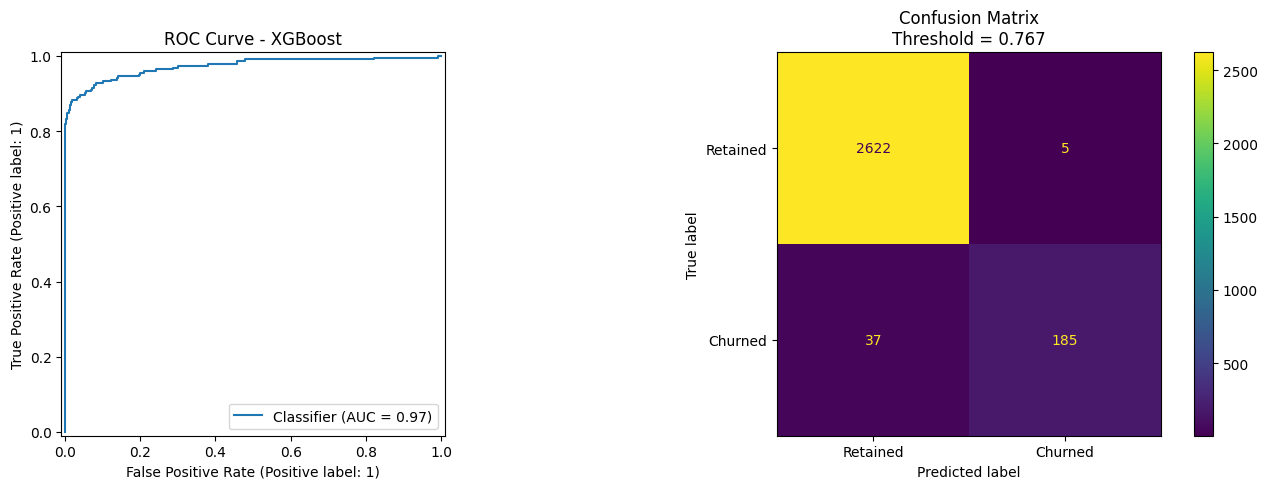

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    confusion_matrix
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=axes[0]
)
axes[0].set_title(f"ROC Curve - {best_model_name}")

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Retained', 'Churned']
).plot(ax=axes[1])

axes[1].set_title(
    f"Confusion Matrix\nThreshold = {best_thresh:.3f}"
)

plt.tight_layout()
plt.savefig("best_churn_model_evaluation.png", dpi=150)
plt.show()

In [ ]:
if best_model_name == "Logistic Regression":

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": abs(best_model.coef_[0])
    })

else:

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                     Feature  Importance
19  Months_Since_Last_Flight    0.585717
7                     Tenure    0.028373
25              Flights_2017    0.028231
15             Active_Months    0.024170
10            Total_Distance    0.021375
12          Total_Points_Red    0.020064
22                Flights_Q3    0.019400
2                Marital_Enc    0.019342
1              Education_Enc    0.019268
26              Flights_2018    0.019124


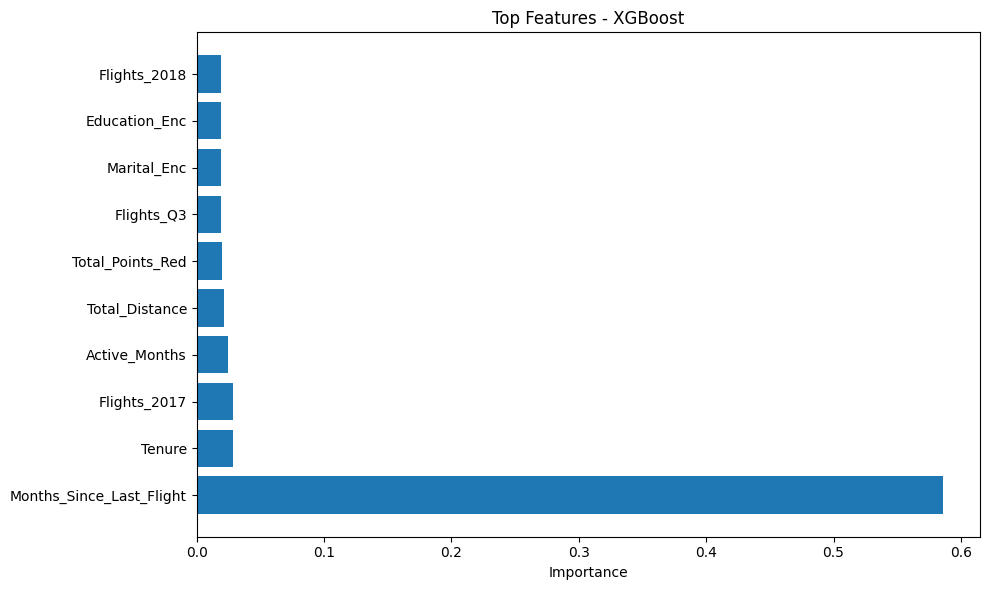

In [ ]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title(f"Top Features - {best_model_name}")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
# Run on full dataset
X_all = df[FEATURES]
df['Churn_Probability'] = best_model.predict_proba(X_all)[:, 1]
df['Risk_Tier'] = pd.cut(df['Churn_Probability'],
                          bins=[0, 0.4, 0.7, 1.0],
                          labels=['Low', 'Medium', 'High'])

df[['Loyalty Number', 'Churn_Probability', 'Risk_Tier', 'Churn']].to_csv('churn_scores.csv', index=False)

Segmentation


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/airlines_churn_prediction/outputs/Modeling_Dataset.csv')
scores = pd.read_csv('churn_scores.csv')
df = df.merge(scores, on='Loyalty Number')

In [ ]:
print(df.shape)
print(df.columns.tolist())

(14243, 35)
['Loyalty Number', 'Male_Enc', 'Education_Enc', 'Marital_Enc', 'Card_Enc', 'Salary_Imputed', 'Salary_Was_Imputed', 'CLV', 'Tenure', 'Promo_Enroll', 'Total_Flights', 'Total_Distance', 'Total_Points_Acc', 'Total_Points_Red', 'Avg_Flights_Month', 'Max_Flights_Month', 'Active_Months', 'Activity_Rate', 'Redemption_Ratio', 'Avg_Distance_Per_Flight', 'Months_Since_Last_Flight', 'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4', 'Flights_Trend', 'Flights_2017', 'Flights_2018', 'Churn_x', 'Formal_Churn', 'Behavioral_Churn', 'Never_Flew', 'Churn_Probability', 'Risk_Tier', 'Churn_y']


In [ ]:
# These 6 features capture the full behavioral picture
seg_features = [
    'Total_Flights',        # Frequency
    'Months_Since_Last_Flight',  # Recency (higher = more inactive)
    'CLV',                  # Monetary / value
    'Redemption_Ratio',     # Engagement quality
    'Flights_Trend',        # Are they flying more or less?
    'Card_Enc'              # Loyalty tier
]

seg_df = df[['Loyalty Number'] + seg_features].copy()
seg_df.fillna(0, inplace=True)

scaler = StandardScaler()
X_seg = scaler.fit_transform(seg_df[seg_features])

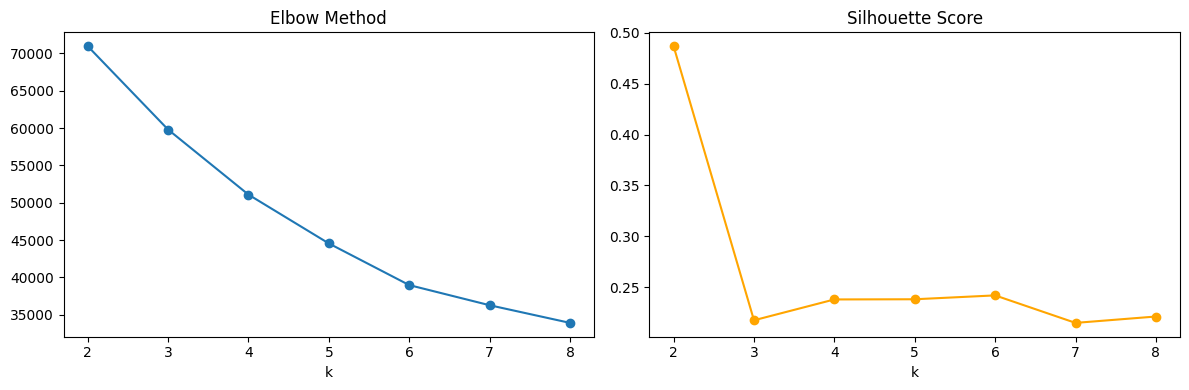

In [ ]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[1].plot(K_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
# Pick k where elbow bends AND silhouette is high — usually k=4 or 5

In [ ]:
for k, s in zip(K_range, silhouettes):
    print(f"k={k}: silhouette={s:.4f}")

k=2: silhouette=0.4869
k=3: silhouette=0.2173
k=4: silhouette=0.2378
k=5: silhouette=0.2380
k=6: silhouette=0.2418
k=7: silhouette=0.2147
k=8: silhouette=0.2210


In [ ]:
BEST_K =4  # adjust after seeing elbow plot

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
seg_df['Segment_ID'] = km_final.fit_predict(X_seg)

# Analyze each cluster to name it
profile = df.copy()
profile = profile.merge(seg_df[['Loyalty Number','Segment_ID']], on='Loyalty Number')

cluster_summary = profile.groupby('Segment_ID').agg(
    Count=('Loyalty Number', 'count'),
    Avg_CLV=('CLV', 'mean'),
    Avg_Flights=('Total_Flights', 'mean'),
    Avg_Recency=('Months_Since_Last_Flight', 'mean'),
    Avg_Redemption=('Redemption_Ratio', 'mean'),
    Avg_ChurnProb=('Churn_Probability', 'mean'),
    Avg_Trend=('Flights_Trend', 'mean')
).round(2)

print(cluster_summary)

            Count   Avg_CLV  Avg_Flights  Avg_Recency  Avg_Redemption  \
Segment_ID                                                              
0            3522   6761.26        18.62         0.76            0.02   
1            6752   5646.38        39.46         0.73            0.02   
2             726   7572.69        12.70        15.48            0.02   
3            3243  14083.73        37.84         0.72            0.02   

            Avg_ChurnProb  Avg_Trend  
Segment_ID                            
0                    0.07      10.96  
1                    0.04      -1.82  
2                    1.00     -11.10  
3                    0.04      -0.27  


In [ ]:
segment_names = {
    0: "Emerging Loyalists",   # Moderate CLV, moderate flights, strong positive flight trend (+10.96)
    1: "Frequent Flyers",      # Highest flight frequency (39.46 flights) with low churn risk
    2: "At-Risk Inactives",    # Extremely high recency (15.48 months since last flight), highest churn risk
    3: "VIP Champions"         # Highest CLV (14083), high flight activity, very low churn risk
}

seg_df['Segment_Name'] = seg_df['Segment_ID'].map(segment_names)

In [ ]:
seg_df['Segment_Name'].value_counts()

,count
Segment_Name,
Frequent Flyers,6752
Emerging Loyalists,3522
VIP Champions,3243
At-Risk Inactives,726


In [ ]:
print(cluster_summary)

            Count   Avg_CLV  Avg_Flights  Avg_Recency  Avg_Redemption  \
Segment_ID                                                              
0            3522   6761.26        18.62         0.76            0.02   
1            6752   5646.38        39.46         0.73            0.02   
2             726   7572.69        12.70        15.48            0.02   
3            3243  14083.73        37.84         0.72            0.02   

            Avg_ChurnProb  Avg_Trend  
Segment_ID                            
0                    0.07      10.96  
1                    0.04      -1.82  
2                    1.00     -11.10  
3                    0.04      -0.27  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Find the dangerous mismatch: high CLV but high churn risk
profile['CLV_Tier'] = pd.qcut(profile['CLV'], q=3, labels=['Low CLV','Mid CLV','High CLV'])

mismatch = profile.groupby(['CLV_Tier', 'Risk_Tier']).size().unstack(fill_value=0)
print("\nCLV vs Churn Risk — the mismatch table:")
print(mismatch)

# High CLV + High Risk = members worth saving urgently
critical = profile[(profile['CLV_Tier']=='High CLV') & (profile['Risk_Tier']=='High')]
print(f"\nCritical members (High CLV + High Churn Risk): {len(critical)}")


CLV vs Churn Risk — the mismatch table:
Risk_Tier  High   Low  Medium
CLV_Tier                     
Low CLV     356  4367      26
Mid CLV     381  4324      41
High CLV    341  4379      28

Critical members (High CLV + High Churn Risk): 341


In [ ]:
print(seg_df.columns)
print(profile.columns)

Index(['Loyalty Number', 'Total_Flights', 'Months_Since_Last_Flight', 'CLV',
       'Redemption_Ratio', 'Flights_Trend', 'Card_Enc', 'Segment_ID',
       'Segment_Name'],
      dtype='object')
Index(['Loyalty Number', 'Male_Enc', 'Education_Enc', 'Marital_Enc',
       'Card_Enc', 'Salary_Imputed', 'Salary_Was_Imputed', 'CLV', 'Tenure',
       'Promo_Enroll', 'Total_Flights', 'Total_Distance', 'Total_Points_Acc',
       'Total_Points_Red', 'Avg_Flights_Month', 'Max_Flights_Month',
       'Active_Months', 'Activity_Rate', 'Redemption_Ratio',
       'Avg_Distance_Per_Flight', 'Months_Since_Last_Flight', 'Flights_Q1',
       'Flights_Q2', 'Flights_Q3', 'Flights_Q4', 'Flights_Trend',
       'Flights_2017', 'Flights_2018', 'Churn_x', 'Formal_Churn',
       'Behavioral_Churn', 'Never_Flew', 'Churn_Probability', 'Risk_Tier',
       'Churn_y', 'Segment_ID', 'CLV_Tier'],
      dtype='object')


In [ ]:
pd.crosstab(seg_df['Segment_Name'], profile['Risk_Tier'])

Risk_Tier,High,Low,Medium
Segment_Name,,,
At-Risk Inactives,726,0,0
Emerging Loyalists,169,3317,36
Frequent Flyers,110,6596,46
VIP Champions,73,3157,13


In [ ]:
output = df[['Loyalty Number', 'CLV', 'Churn_Probability', 'Risk_Tier', 'Churn_x']].copy()

output = output.merge(
    seg_df[['Loyalty Number', 'Segment_ID', 'Segment_Name']],
    on='Loyalty Number',
    how='left'
)

output.to_csv('segments.csv', index=False)
print("Saved segments.csv")

Saved segments.csv
